# Fitbit Fitness Tracker — Exploratory Data Analysis

**Case study reference:** Bellabeat / Strava-style wellness device usage analysis
**Dataset:** 33 Fitbit users, day- and hour-level tracking data, 12 Apr – 12 May 2016
(public domain, CC0, distributed via Amazon Mechanical Turk)

This notebook explores the merged dataset produced in the data-merging step
(`daily_merged.csv`, `hourly_merged.csv` — outer-joined from the 19 raw export files,
**no values corrected or altered**) and answers a set of concrete questions about how
people actually use their fitness tracker:

1. How does activity change through the week, and through the day?
2. How much does behaviour vary *between participants*, versus *between weekdays*?
3. How are steps, calories, active time, sedentary time and sleep related to each other?
4. Is there a meaningful weekday vs. weekend difference?
5. How consistent is each participant's routine?

Every chart below has a one-line takeaway underneath it, and every code cell is commented
so the *why*, not just the *what*, is clear. Heatmaps show the actual averaged number in
each cell, not just a color, so they can be read precisely rather than estimated by eye.

**Tools:** `pandas` for aggregation, `matplotlib` / `seaborn` for visualization — the
"Python (Matplotlib, seaborn) — to visualize" step from the project plan. SQL-based
analysis and the interactive dashboard live in the companion Streamlit app.


## 1. Setup & Data Load

In [1]:
# --- Core libraries ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A consistent, readable theme for every chart in this notebook
sns.set_theme(style="whitegrid")

# Calendar order for weekday axes/groupbys — without this, pandas/matplotlib
# would sort weekdays alphabetically (Friday, Monday, Saturday, ...), which
# is not how anyone reads a weekly pattern
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# --- Load the merged files (produced by the earlier merge step) -------------
daily = pd.read_csv("daily_merged.csv")     # one row per participant per day
hourly = pd.read_csv("hourly_merged.csv")   # one row per participant per hour

# --- Derived columns for analysis only — the underlying source values are
#     never modified, these are purely computed on top for grouping/plotting
daily["Date_dt"] = pd.to_datetime(daily["Date"], errors="coerce")
daily["Weekday"] = pd.Categorical(daily["Date_dt"].dt.day_name(),
                                   categories=WEEKDAY_ORDER, ordered=True)
daily["IsWeekend"] = daily["Weekday"].isin(["Saturday", "Sunday"])
daily["TotalActiveMinutes"] = (daily["LightlyActiveMinutes"]
                                + daily["FairlyActiveMinutes"]
                                + daily["VeryActiveMinutes"])
daily["SedentaryHours"] = daily["SedentaryMinutes"] / 60.0
daily["SleepHours"] = daily["TotalMinutesAsleep"] / 60.0

hourly["ActivityHour_dt"] = pd.to_datetime(hourly["ActivityHour"], errors="coerce")
hourly["Hour"] = hourly["ActivityHour_dt"].dt.hour
hourly["Weekday"] = pd.Categorical(hourly["ActivityHour_dt"].dt.day_name(),
                                    categories=WEEKDAY_ORDER, ordered=True)

print("daily_merged:", daily.shape, "| unique participants:", daily["Id"].nunique())
print("hourly_merged:", hourly.shape)

daily_merged: (943, 25) | unique participants: 33
hourly_merged: (22099, 6)

## 2. Data Integrity Check
Quick pass matching the project's "Data-set Integrity Check" step: confirm there are no
nulls in the core activity fields, no duplicate participant-day rows introduced by the
merge, and the collection window is what we expect.

In [1]:
# Nulls are expected in sleep/weight fields (not everyone logs those every day) but
# should be ZERO in the core activity fields that every Fitbit records automatically
print("Missing values in core activity fields:")
print(daily[["TotalSteps", "Calories", "SedentaryMinutes", "VeryActiveMinutes"]].isna().sum())

# A duplicate Id+Date row would mean the merge accidentally fan-outed some days —
# checking this also surfaces duplicates that already existed in a *source* file
dup_count = daily.duplicated(subset=["Id", "Date"]).sum()
print("\nDuplicate Id+Date rows:", dup_count)

print("Date range:", daily["Date_dt"].min().date(), "to", daily["Date_dt"].max().date())

Missing values in core activity fields:
TotalSteps           0
Calories             0
SedentaryMinutes     0
VeryActiveMinutes    0
dtype: int64

Duplicate Id+Date rows: 3
Date range: 2016-04-12 to 2016-05-12

The 3 duplicates trace back to **exact duplicate rows already present in the raw `sleepDay_merged.csv` source file** (same Id, same night, identical sleep values) — not something introduced by the merge step. Per the project's "don't correct the data" rule, they were kept as outer-joined rather than silently dropped; worth knowing about before treating per-day row counts as exact.

## 3. Weekly Activity Pattern

### 3.1 Average Steps Taken Through Weekdays
**Takeaway:** Sunday is the lowest day (~6,900 steps); Tuesday and Saturday are highest (~8,100-8,200). The overall spread is fairly mild — every weekday still averages well above 6,900 steps.

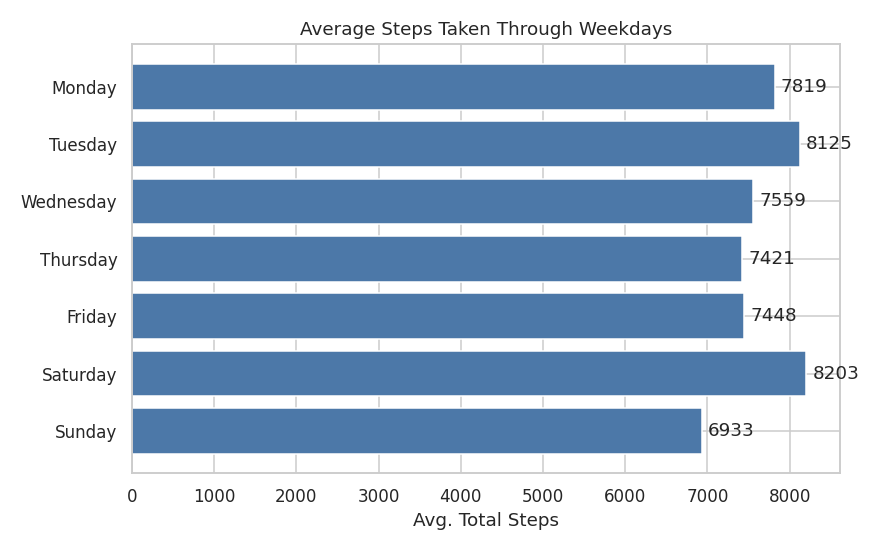

In [1]:
# Group by weekday and average steps across all participants and dates,
# then reindex to force calendar order (Mon-Sun) instead of alphabetical order
steps_wd = daily.groupby("Weekday", observed=True)["TotalSteps"].mean().reindex(WEEKDAY_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(steps_wd.index[::-1], steps_wd.values[::-1], color="#4C78A8")
ax.bar_label(bars, fmt="%.0f", padding=4)   # print the exact value at the end of each bar
ax.set_xlabel("Avg. Total Steps")
ax.set_title("Average Steps Taken Through Weekdays")
plt.tight_layout()
plt.show()

### 3.2 Participants' Average Steps by Weekday (Heatmap)
Per-participant breakdown — **numbers are the actual average step count in each cell**, not just a color scale. This shows which individuals drive the weekday pattern above, versus who is consistently low or high activity regardless of day.

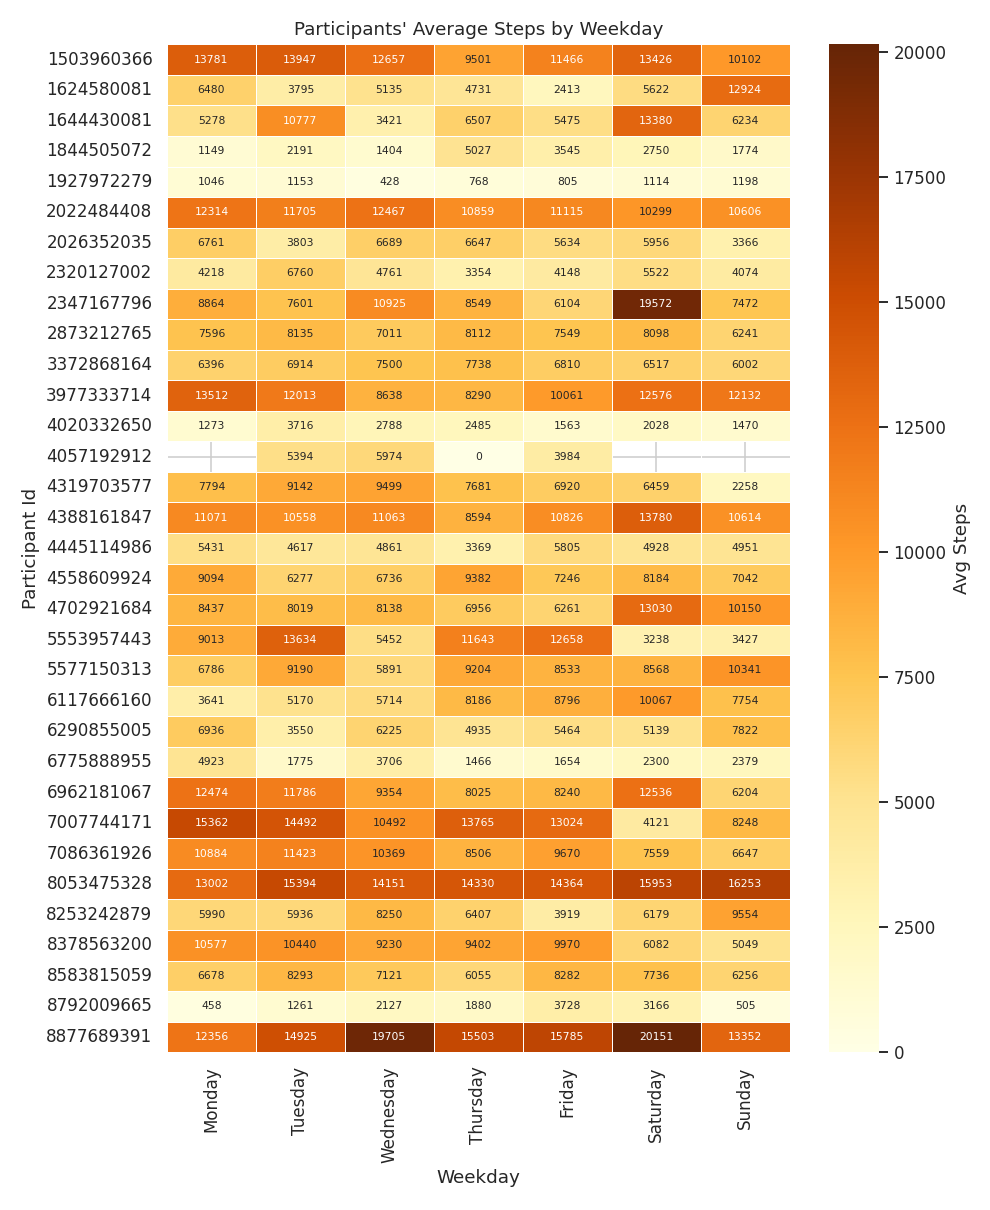

In [1]:
# pivot_table: rows = participant Id, columns = Weekday, values = mean steps.
# observed=True avoids generating empty categories that don't exist in the data.
pivot_steps = daily.pivot_table(index="Id", columns="Weekday", values="TotalSteps",
                                 aggfunc="mean", observed=True).reindex(columns=WEEKDAY_ORDER)

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(
    pivot_steps, cmap="YlOrBr",
    annot=True, fmt=".0f", annot_kws={"size": 7},   # <-- print the real number in every cell
    cbar_kws={"label": "Avg Steps"}, linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_title("Participants' Average Steps by Weekday")
ax.set_ylabel("Participant Id")
plt.tight_layout()
plt.show()

### 3.3 Participants' Pattern of Being Sedentary (Heatmap)
**Takeaway:** most participants log 500-900+ sedentary minutes on most days (8-15+ hours) — this is the single most consistent pattern in the whole dataset, far more consistent than any weekday effect.

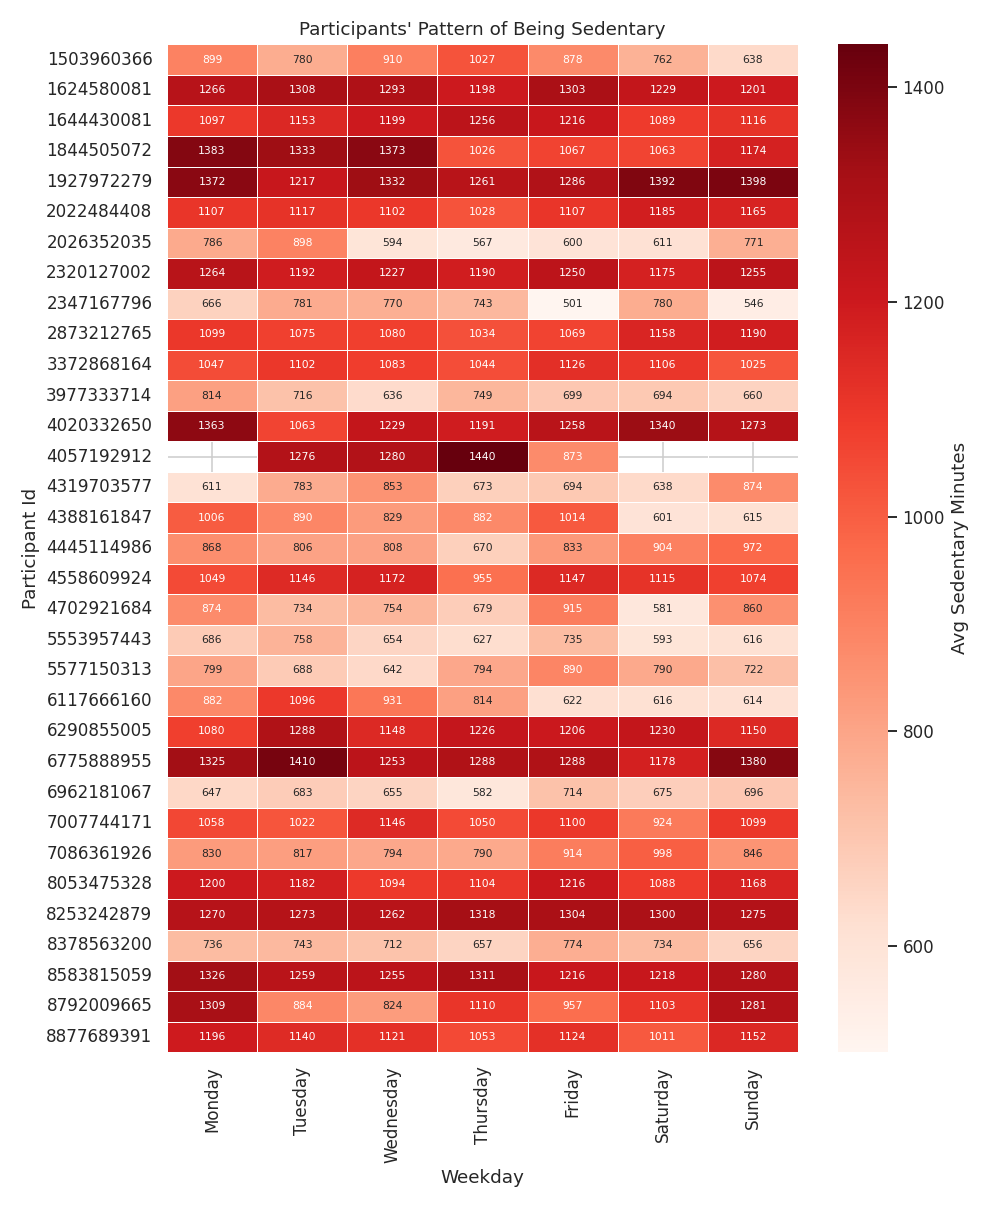

In [1]:
pivot_sed = daily.pivot_table(index="Id", columns="Weekday", values="SedentaryMinutes",
                               aggfunc="mean", observed=True).reindex(columns=WEEKDAY_ORDER)

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(
    pivot_sed, cmap="Reds",
    annot=True, fmt=".0f", annot_kws={"size": 7},
    cbar_kws={"label": "Avg Sedentary Minutes"}, linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_title("Participants' Pattern of Being Sedentary")
ax.set_ylabel("Participant Id")
plt.tight_layout()
plt.show()

### 3.4 Time Spent in Different Activity Categories
**Takeaway:** lightly-active minutes (~193 min/day) dominate over fairly-active (~14 min) and very-active (~21 min) — most of participants' "active" time is genuinely light activity, not exercise.

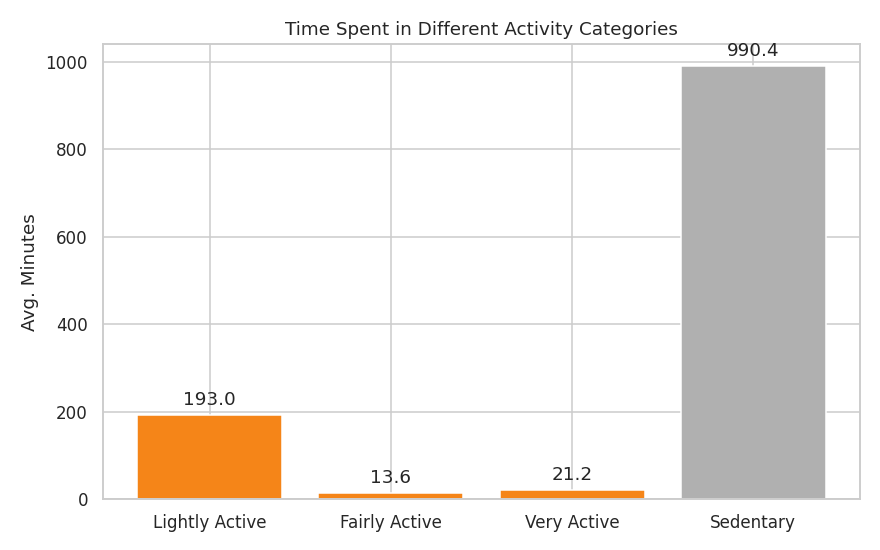

In [1]:
cat_means = daily[["LightlyActiveMinutes", "FairlyActiveMinutes",
                    "VeryActiveMinutes", "SedentaryMinutes"]].mean()
cat_means = cat_means.rename({
    "LightlyActiveMinutes": "Lightly Active", "FairlyActiveMinutes": "Fairly Active",
    "VeryActiveMinutes": "Very Active", "SedentaryMinutes": "Sedentary",
})

fig, ax = plt.subplots(figsize=(8, 5))
# Grey out "Sedentary" so the three genuinely-active categories stand out visually
colors = ["#F58518" if c != "Sedentary" else "#B0B0B0" for c in cat_means.index]
bars = ax.bar(cat_means.index, cat_means.values, color=colors)
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set_ylabel("Avg. Minutes")
ax.set_title("Time Spent in Different Activity Categories")
plt.tight_layout()
plt.show()

### 3.5 Avg. Calories Burnt vs. Avg. Total Active Minutes by Weekday
**Takeaway:** calories broadly track active minutes, with Thursday standing out as a low point on both — a useful anchor for the "low engagement day" recommendation later.

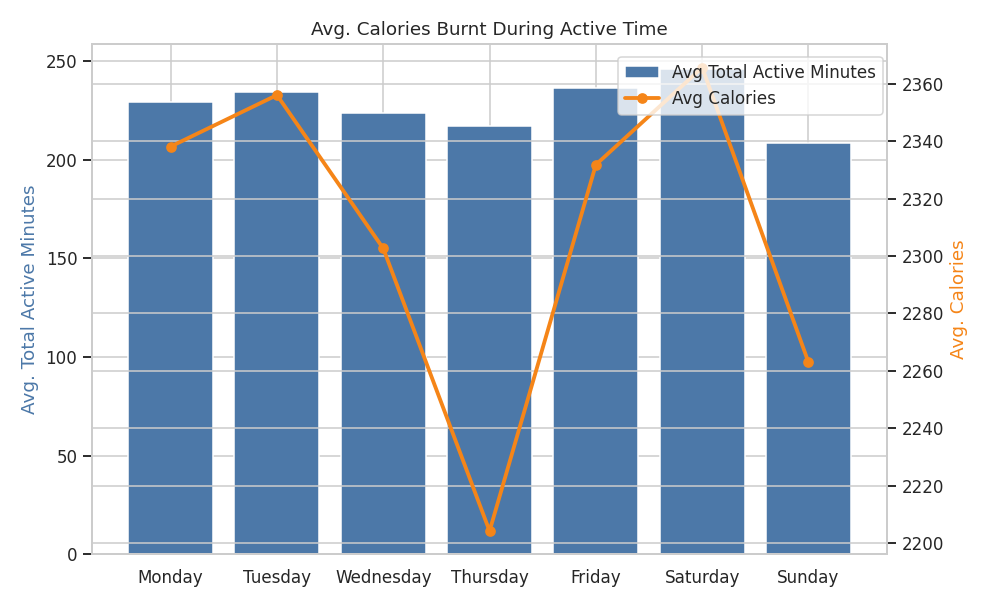

In [1]:
daily["TotalActiveMinutes"] = (daily["LightlyActiveMinutes"]
                                + daily["FairlyActiveMinutes"] + daily["VeryActiveMinutes"])
combo = daily.groupby("Weekday", observed=True)[["Calories", "TotalActiveMinutes"]] \
             .mean().reindex(WEEKDAY_ORDER)

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.bar(combo.index, combo["TotalActiveMinutes"], color="#4C78A8", label="Avg Total Active Minutes")
ax1.set_ylabel("Avg. Total Active Minutes", color="#4C78A8")

ax2 = ax1.twinx()  # secondary y-axis so calories (large numbers) don't flatten the minutes bars
ax2.plot(combo.index, combo["Calories"], color="#F58518", marker="o", linewidth=2.5, label="Avg Calories")
ax2.set_ylabel("Avg. Calories", color="#F58518")

ax1.set_title("Avg. Calories Burnt During Active Time")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.92))
plt.tight_layout()
plt.show()

### 3.6 Avg. Calories Burnt by Participants (Heatmap)
**Takeaway:** calorie burn varies far more *between individuals* (e.g. ~1,600 vs ~3,600 avg/day) than between weekdays for the same individual — body size/metabolism dominates over day-of-week timing.

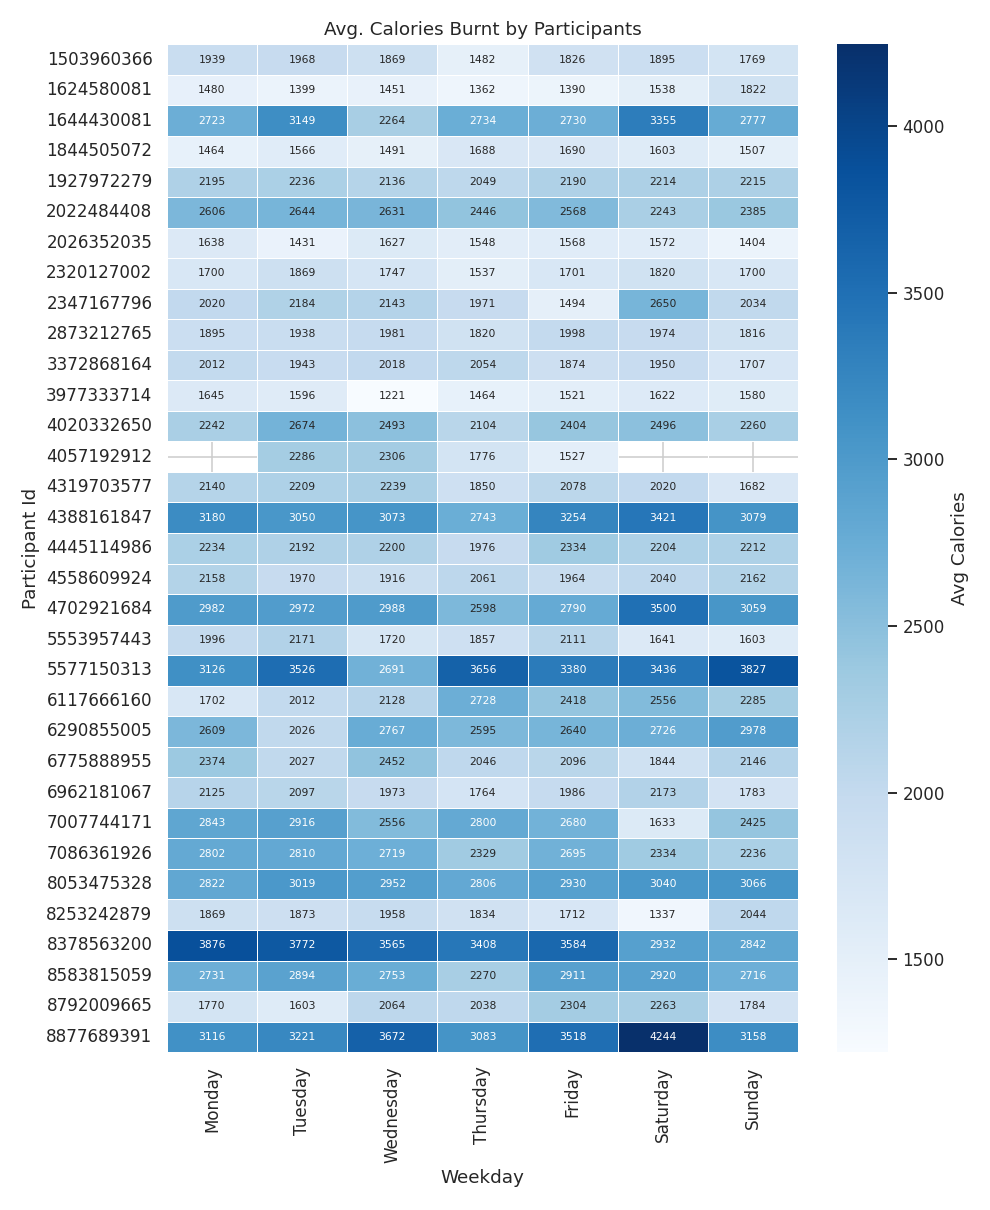

In [1]:
pivot_cal = daily.pivot_table(index="Id", columns="Weekday", values="Calories",
                               aggfunc="mean", observed=True).reindex(columns=WEEKDAY_ORDER)

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(
    pivot_cal, cmap="Blues",
    annot=True, fmt=".0f", annot_kws={"size": 7},
    cbar_kws={"label": "Avg Calories"}, linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_title("Avg. Calories Burnt by Participants")
ax.set_ylabel("Participant Id")
plt.tight_layout()
plt.show()

## 4. Daily Rhythm (Hour-of-Day Patterns)

### 4.1 Calories Burnt Each Hour
**Takeaway:** a clear midday/evening peak (~12:00-19:00, peaking at 18:00) and an overnight trough — matching normal waking-hours activity.

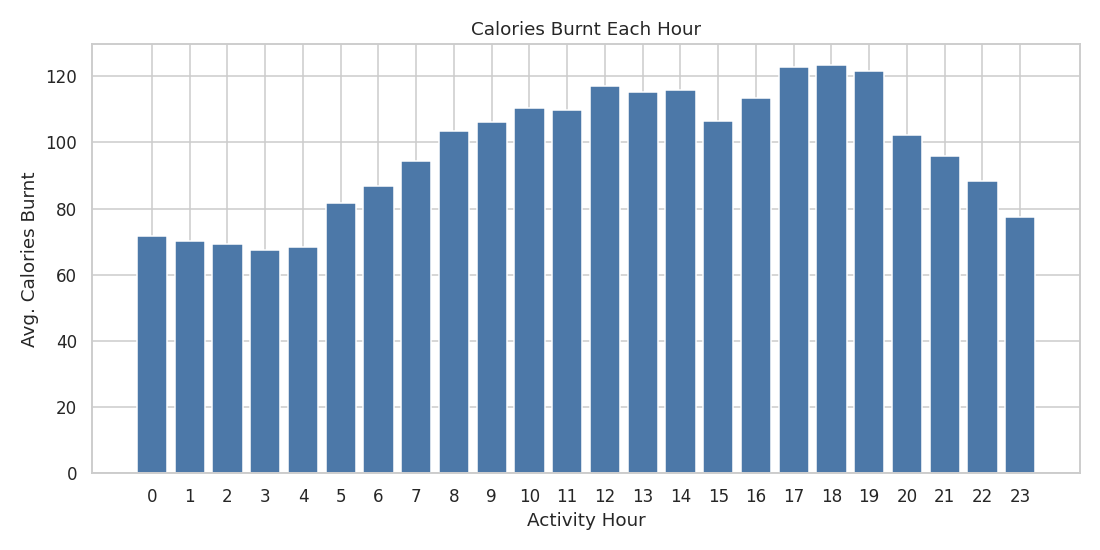

Peak calorie hour: 18 - 123.5 avg calories

In [1]:
cal_hr = hourly.groupby("Hour")["Calories"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cal_hr.index, cal_hr.values, color="#4C78A8")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Activity Hour")
ax.set_ylabel("Avg. Calories Burnt")
ax.set_title("Calories Burnt Each Hour")
plt.tight_layout()
plt.show()

print("Peak calorie hour:", int(cal_hr.idxmax()), "-", round(cal_hr.max(), 1), "avg calories")

### 4.2 Average Steps Taken Each Hour
**Takeaway:** steps peak at the same time as calories (18:00, ~600 steps/hour on average) — confirms the evening peak is genuinely a walking/activity peak, not just a metabolic artifact.

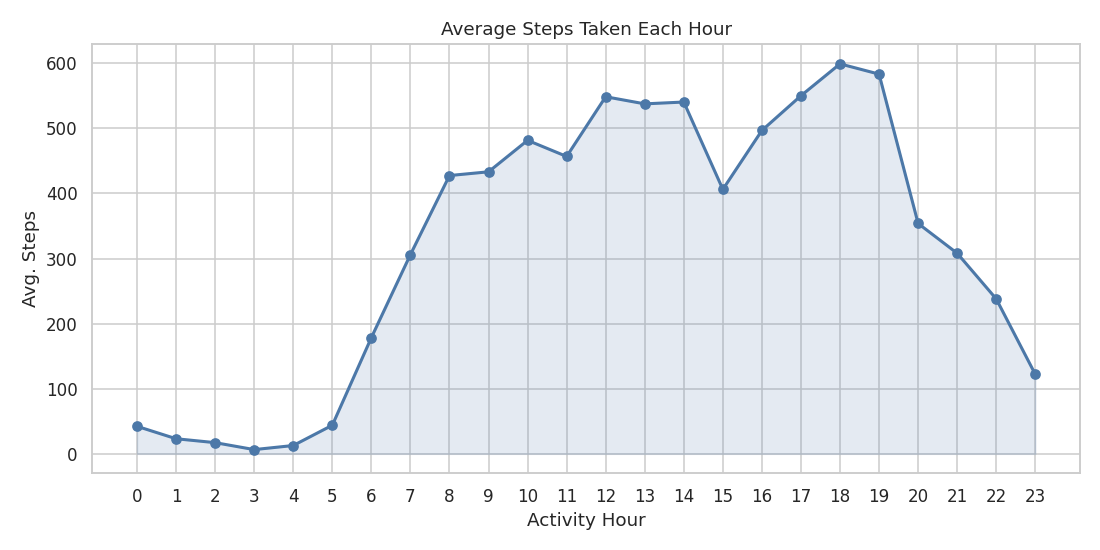

Peak step hour: 18 - 599.2 avg steps

In [1]:
steps_hr = hourly.groupby("Hour")["StepTotal"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps_hr.index, steps_hr.values, color="#4C78A8", marker="o", linewidth=2)
ax.fill_between(steps_hr.index, steps_hr.values, color="#4C78A8", alpha=0.15)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Activity Hour")
ax.set_ylabel("Avg. Steps")
ax.set_title("Average Steps Taken Each Hour")
plt.tight_layout()
plt.show()

print("Peak step hour:", int(steps_hr.idxmax()), "-", round(steps_hr.max(), 1), "avg steps")

## 5. Trend Over the Collection Period

### 5.1 Average Steps Over Time (with 7-day moving average)
**Takeaway:** day-to-day steps are noisy, but the 7-day moving average stays fairly flat across the ~1-month window — no strong upward or downward trend over the study period.

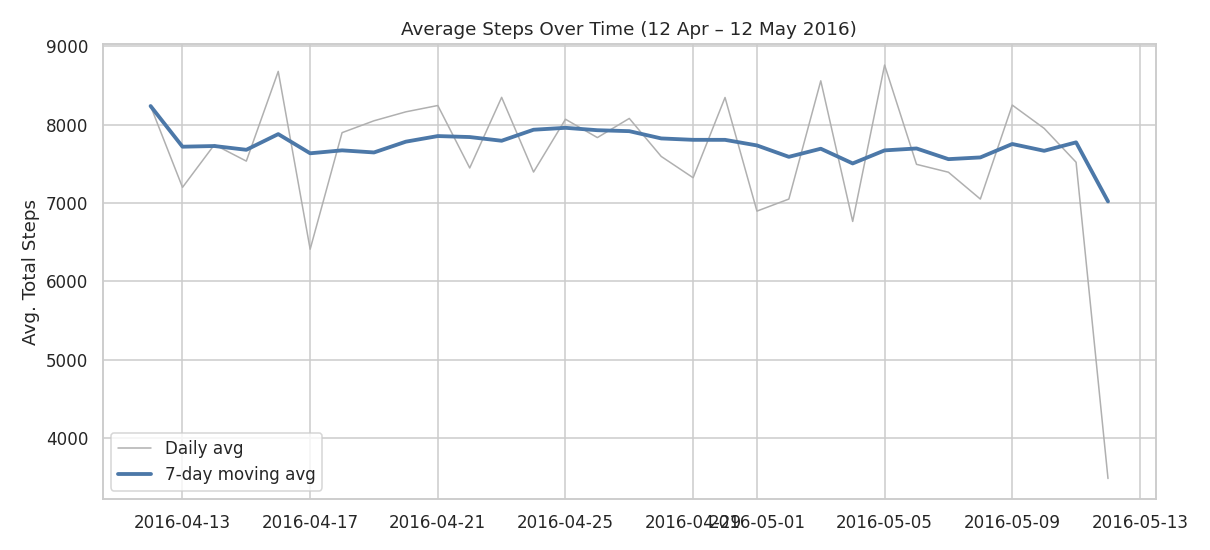

In [1]:
daily_trend = daily.groupby("Date_dt")["TotalSteps"].mean().sort_index()
# A 7-day rolling mean smooths out day-to-day noise so any real trend is easier to see
moving_avg = daily_trend.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily_trend.index, daily_trend.values, color="#B0B0B0", linewidth=1, label="Daily avg")
ax.plot(moving_avg.index, moving_avg.values, color="#4C78A8", linewidth=2.5, label="7-day moving avg")
ax.set_ylabel("Avg. Total Steps")
ax.set_title("Average Steps Over Time (12 Apr - 12 May 2016)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Distributions

### 6.1 Distribution of Daily Steps
**Takeaway:** right-skewed — most participant-days cluster below the mean, with a long tail of high-step days pulling the average up. The median day is lower-activity than the mean suggests.

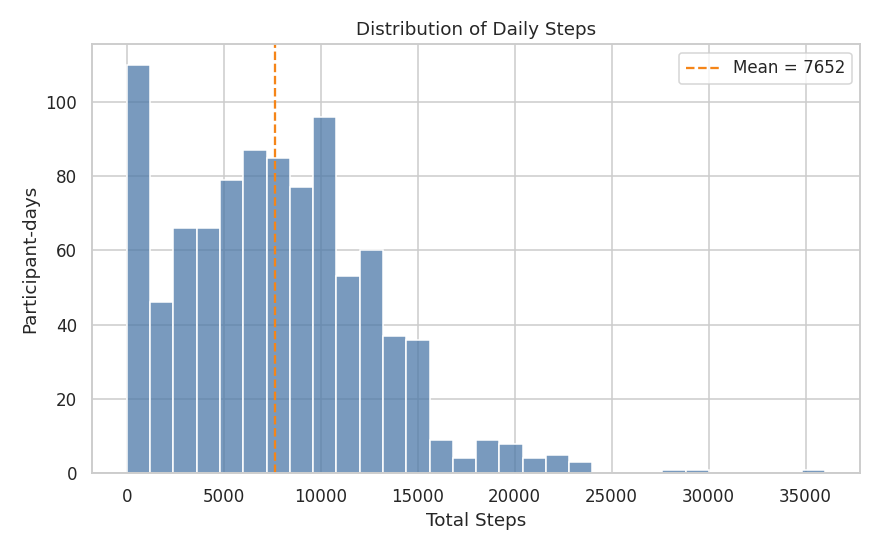

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(daily["TotalSteps"], bins=30, color="#4C78A8", ax=ax)
ax.axvline(daily["TotalSteps"].mean(), color="#F58518", linestyle="--",
           label=f"Mean = {daily['TotalSteps'].mean():.0f}")
ax.set_xlabel("Total Steps")
ax.set_ylabel("Participant-days")
ax.set_title("Distribution of Daily Steps")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Distribution of Daily Calories
**Takeaway:** roughly bell-shaped and much tighter than steps — calories have a large fixed component (basal metabolic rate) that doesn't swing with activity the way steps do.

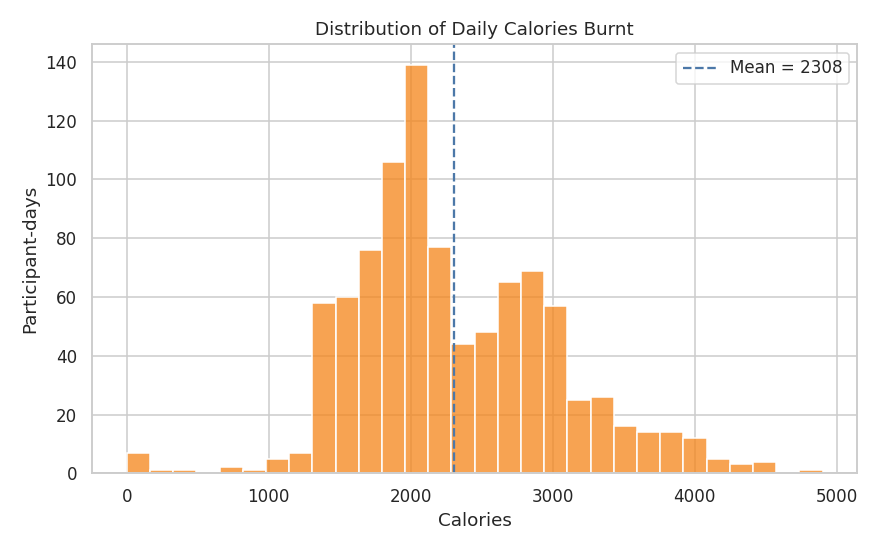

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(daily["Calories"], bins=30, color="#F58518", ax=ax)
ax.axvline(daily["Calories"].mean(), color="#4C78A8", linestyle="--",
           label=f"Mean = {daily['Calories'].mean():.0f}")
ax.set_xlabel("Calories")
ax.set_ylabel("Participant-days")
ax.set_title("Distribution of Daily Calories Burnt")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Relationships Between Metrics

### 7.1 Active Minutes vs. Calories Burnt
**Takeaway:** a clear positive relationship, but with real scatter — active minutes alone explain some, not most, of the variation in calories (consistent with the modest r = 0.47 seen in the correlation heatmap below).

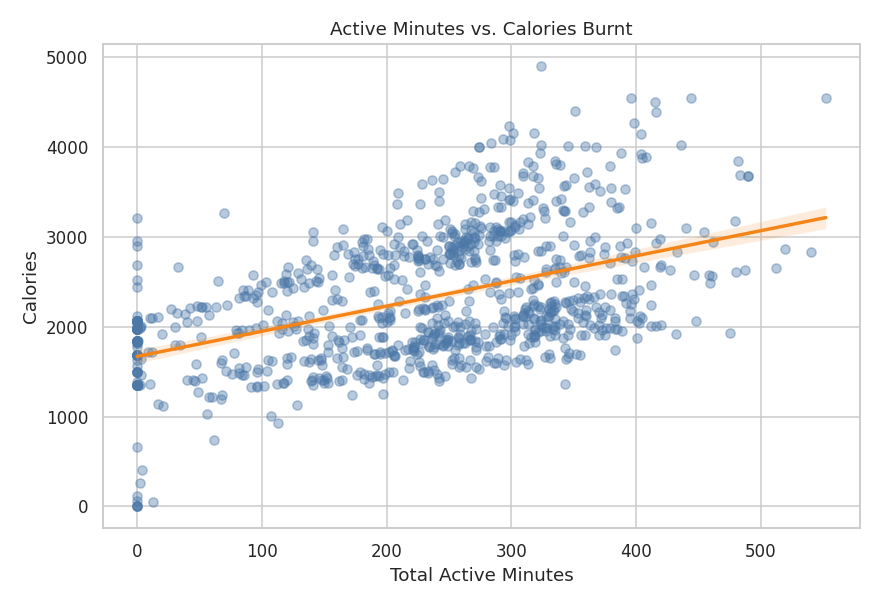

In [1]:
fig, ax = plt.subplots(figsize=(8, 5.5))
# regplot draws the scatter AND a fitted linear trend line in one call
sns.regplot(data=daily, x="TotalActiveMinutes", y="Calories",
            scatter_kws={"alpha": 0.4, "color": "#4C78A8"}, line_kws={"color": "#F58518"}, ax=ax)
ax.set_xlabel("Total Active Minutes")
ax.set_ylabel("Calories")
ax.set_title("Active Minutes vs. Calories Burnt")
plt.tight_layout()
plt.show()

### 7.2 Correlation Between Key Daily Metrics
**Takeaway:** Active minutes correlate most strongly with steps (0.77); sedentary minutes correlate negatively with both active minutes (-0.48) and sleep (-0.60) — participants who sit more also tend to sleep less, one of the clearer relationships in the data.

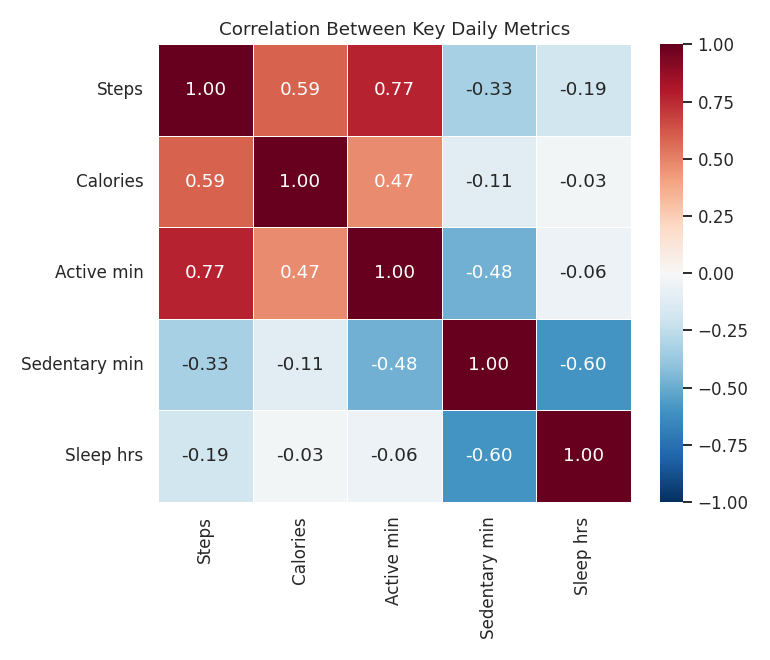

In [1]:
corr_cols = ["TotalSteps", "Calories", "TotalActiveMinutes", "SedentaryMinutes", "SleepHours"]
corr = daily[corr_cols].corr().round(2)
corr.index = corr.columns = ["Steps", "Calories", "Active min", "Sedentary min", "Sleep hrs"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Correlation Between Key Daily Metrics")
plt.tight_layout()
plt.show()

## 8. Weekday vs. Weekend Behaviour
**Takeaway:** weekday and weekend behaviour is surprisingly similar for steps and active minutes. The clearest difference is sleep — participants sleep about 23 minutes longer on weekends than on weekdays.

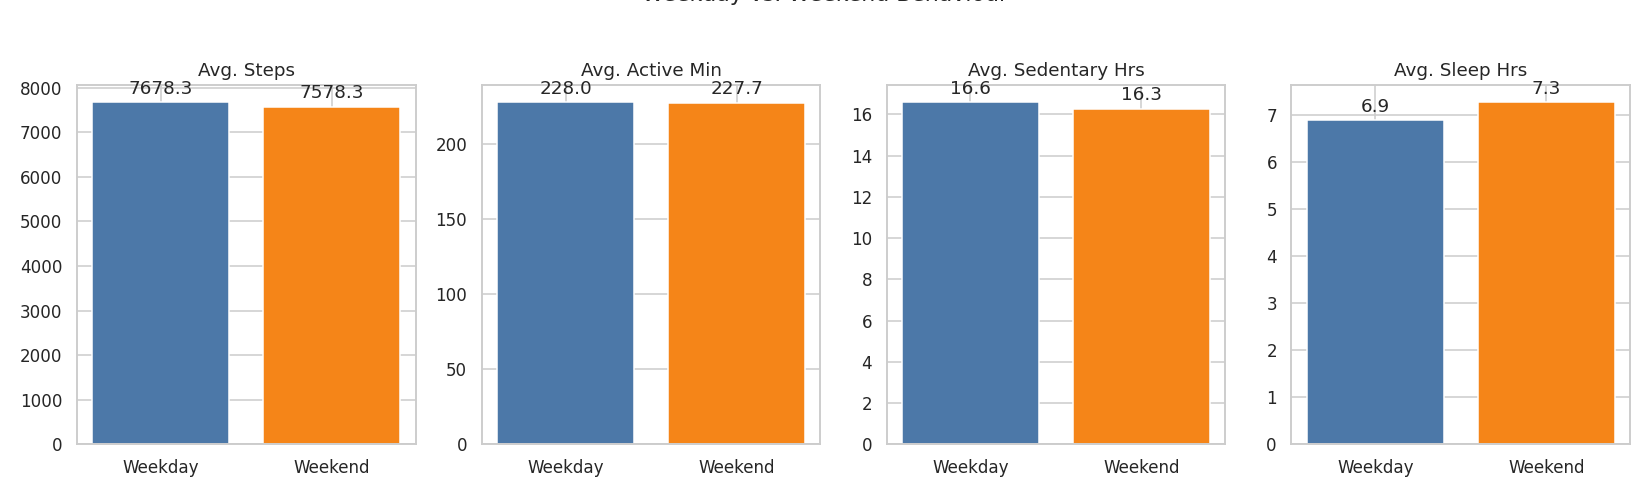

In [1]:
wd_we = daily.groupby("IsWeekend", observed=True)[
    ["TotalSteps", "TotalActiveMinutes", "SedentaryHours", "SleepHours"]
].mean()
wd_we.index = ["Weekday", "Weekend"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
metrics = ["TotalSteps", "TotalActiveMinutes", "SedentaryHours", "SleepHours"]
titles = ["Avg. Steps", "Avg. Active Min", "Avg. Sedentary Hrs", "Avg. Sleep Hrs"]
for ax, m, t in zip(axes, metrics, titles):
    bars = ax.bar(wd_we.index, wd_we[m], color=["#4C78A8", "#F58518"])
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_title(t)
fig.suptitle("Weekday vs. Weekend Behaviour", y=1.03)
plt.tight_layout()
plt.show()

## 9. Sleep

### 9.1 Distribution of Nightly Sleep
**Takeaway:** a meaningful share of nights fall short of the commonly-cited 7-hour guideline (dashed line) — sleep is the wellness metric most worth calling out in the recommendations.

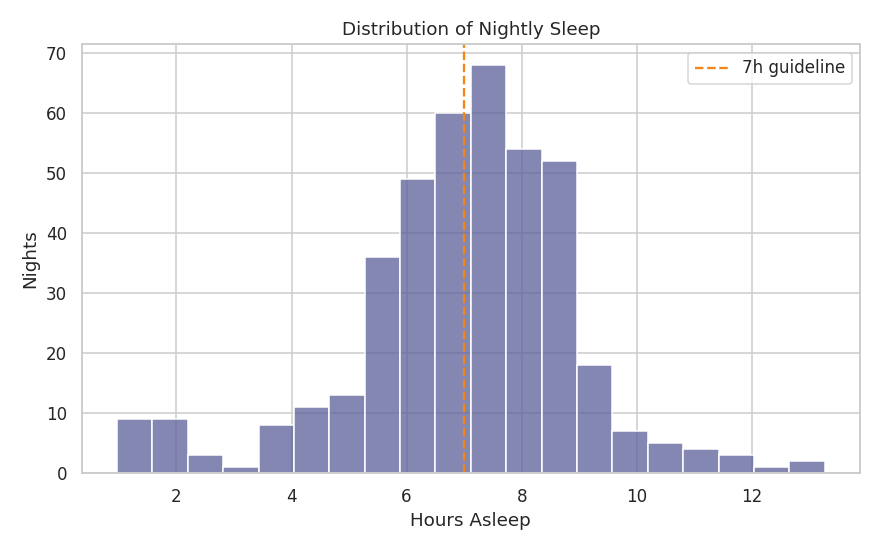

In [1]:
sleep_d = daily[daily["TotalMinutesAsleep"].notna()]

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(sleep_d["SleepHours"], bins=20, color="#5B5F97", ax=ax)
ax.axvline(7, color="#F58518", linestyle="--", label="7h guideline")
ax.set_xlabel("Hours Asleep")
ax.set_ylabel("Nights")
ax.set_title("Distribution of Nightly Sleep")
ax.legend()
plt.tight_layout()
plt.show()

### 9.2 Sleep Hours vs. Same-day Steps
**Takeaway:** a slight *negative* trend — nights with more sleep are (weakly) associated with fewer steps the same day, plausibly because very active days can cut into sleep, or because rest days combine more sleep with less movement.

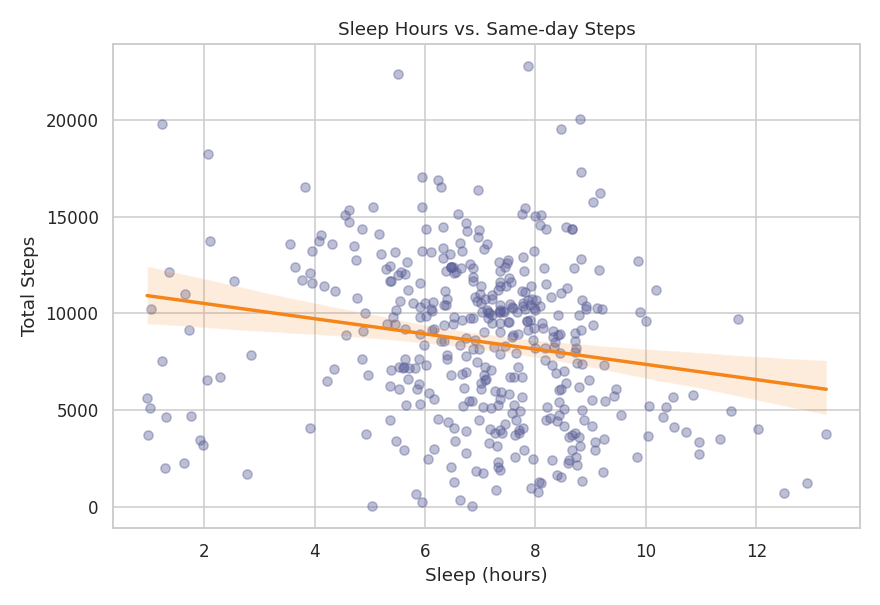

In [1]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=sleep_d, x="SleepHours", y="TotalSteps",
            scatter_kws={"alpha": 0.4, "color": "#5B5F97"}, line_kws={"color": "#F58518"}, ax=ax)
ax.set_xlabel("Sleep (hours)")
ax.set_ylabel("Total Steps")
ax.set_title("Sleep Hours vs. Same-day Steps")
plt.tight_layout()
plt.show()

## 10. Spread and Participant Consistency

### 10.1 Spread of Sedentary Hours by Weekday
A boxplot instead of a bar chart on purpose — the earlier weekday charts only show the *average*. This shows the full spread, so we can see how wide the variation is within each day, not just between days. **Takeaway:** the spread within any single weekday (the box height) is much larger than the difference between weekday averages — day-of-week explains relatively little of the variation in sedentary time.

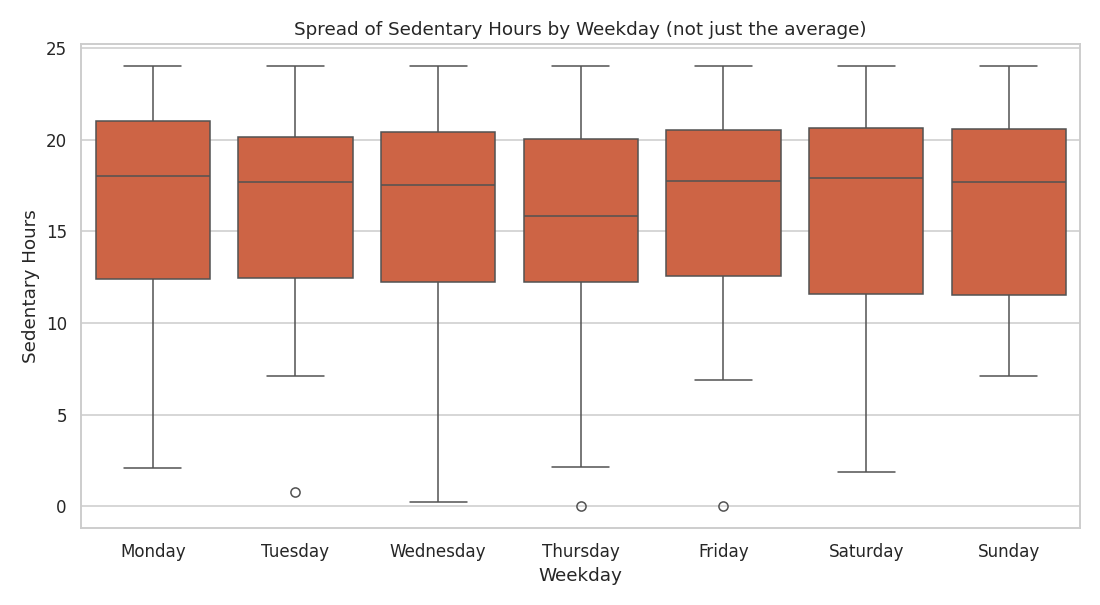

In [1]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=daily, x="Weekday", y="SedentaryHours", order=WEEKDAY_ORDER, color="#E4572E", ax=ax)
ax.set_ylabel("Sedentary Hours")
ax.set_title("Spread of Sedentary Hours by Weekday (not just the average)")
plt.tight_layout()
plt.show()

### 10.2 Top 10 Participants by Average Steps
**Takeaway:** the most active participant averages roughly 3x the steps of a typical participant — reinforcing that *who* the person is matters more than *what day* it is.

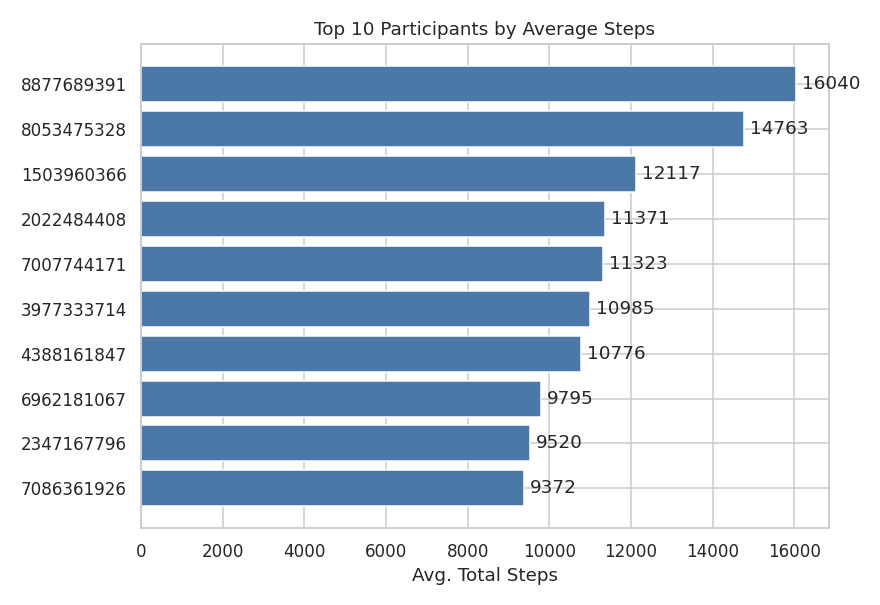

In [1]:
top10 = daily.groupby("Id", observed=True)["TotalSteps"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(top10.index[::-1].astype(str), top10.values[::-1], color="#4C78A8")
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_xlabel("Avg. Total Steps")
ax.set_title("Top 10 Participants by Average Steps")
plt.tight_layout()
plt.show()

### 10.3 Consistency of Each Participant's Routine
Coefficient of variation (std / mean) of daily steps — **lower means a steadier day-to-day routine**, higher means the participant swings between very active and very inactive days. Only participants with 14+ logged days are included, so the estimate is reasonably stable. **Takeaway:** consistency varies a lot by individual and is a separate trait from being "active" — some of the most active participants are also among the least consistent.

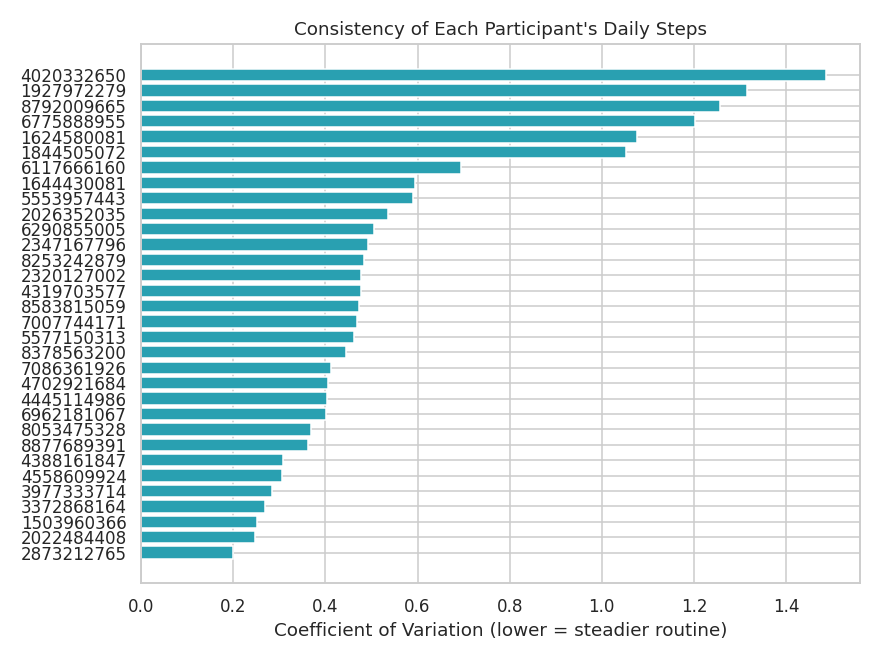

In [1]:
grp = daily.groupby("Id", observed=True)["TotalSteps"]
cv = (grp.std() / grp.mean()).dropna().sort_values()
cv = cv[grp.count().reindex(cv.index) >= 14]   # keep only well-sampled participants

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(cv.index.astype(str), cv.values, color="#29A0B1")
ax.set_xlabel("Coefficient of Variation (lower = steadier routine)")
ax.set_title("Consistency of Each Participant's Daily Steps")
plt.tight_layout()
plt.show()

## 11. Summary

- **Sedentary time dominates the day** — participants average ~16.5 hours/day sedentary, far outweighing
  the ~3.8 hours of combined light/fairly/very-active time (Section 3.3, 3.4).
- **Weekday pattern is mild, not dramatic** — steps range from ~6,900 (Sunday) to ~8,200 (Saturday);
  calories follow active minutes fairly closely except for a Thursday dip (Section 3.1, 3.5).
- **Individual variation >> weekday variation** — the participant-level heatmaps (3.2, 3.3, 3.6) and the
  boxplot (10.1) all show far bigger swings between *people* than between *days*.
- **Activity is concentrated in the evening** — both calories and steps peak around 18:00 and dip
  overnight (Section 4).
- **No strong trend over the month** — the 7-day moving average of steps stays roughly flat across the
  full collection period (Section 5).
- **Weekday vs. weekend is close, except sleep** — participants sleep noticeably longer on weekends
  (Section 8).
- **Sedentary time and sleep are negatively correlated (-0.60)** — the strongest relationship in the
  correlation heatmap besides steps/active-minutes (Section 7.2).
- **Sleep runs slightly under recommendation** — many nights fall short of the CDC's 7-hour guideline
  (Section 9.1), and more sleep is weakly associated with *fewer* steps the same day (Section 9.2).
- **Consistency is its own trait** — some highly active participants are also highly inconsistent
  day-to-day (Section 10.3), which matters for how "on-track" nudges should be designed.

## 12. Recommendations

1. **Sedentary-break nudges** (highest impact): trigger a move reminder after a set period of inactivity —
   this is the single largest and most consistent pattern in the data.
2. **Evening engagement window**: schedule motivational nudges/challenges around 17:00-19:00, the observed
   peak activity window for both steps and calories, rather than a flat all-day schedule.
3. **Personalize over generalize**: because between-participant variation dwarfs between-weekday variation
   for steps, calories, and sedentary time, target goals per-user (their own rolling average) rather than a
   single weekday-based campaign.
4. **Weekend wind-down, not weekend push**: since weekend behaviour is already close to weekday behaviour
   except for (healthier) longer sleep, weekend messaging should protect that extra sleep rather than push
   for more activity.
5. **Consistency-aware coaching**: participants with high day-to-day variability (Section 10.3) may benefit
   more from "keep a streak going" messaging than participants who are already steady but simply low-volume.
